# Feature Store Patterns on Real Case-Study Artifacts

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Section 26.6
**Prerequisites**: Familiarity with feature engineering and Chapter 25 deployment verification.

**Learning Objectives**:
- Describe a table of features the way a feature store does: which column identifies the
  thing being described, which column says when the value was true, and how long a value
  stays usable.
- Assemble a training set by joining each feature to the moment it was known, and add a
  check that refuses to build one that reaches past the date the model may not see.
- Assemble the same feature vector the way a live system would, from the latest value known
  at the moment of the decision.
- Measure what changes when the timestamp rule is wrong by one session.

A **feature store** is the component that answers one question in two places: what were this
thing's features at this moment. Training asks it for millions of past moments at once;
a live system asks it for one moment, now. When the two answers are produced by different
code, they drift apart, and a model trained on one is served the other. The drift is called
**training-serving skew**, and it is the failure this whole component exists to prevent.

Nothing below imports a feature store. The tasks are done directly against the case study's
own Parquet files, so what a store automates stays visible. `05b_feast_live` runs the same
workflow through Feast.

In [1]:
"""Feature Store Patterns on Real Case-Study Artifacts: point-in-time joins, as-of serving, and the skew between them."""

'Feature Store Patterns on Real Case-Study Artifacts: point-in-time joins, as-of serving, and the skew between them.'

## Settings

`TRAINING_START`, `TRAINING_END` and `AS_OF_DATE` bound the two retrievals: the offline
training window, and the single moment the live system is asked about. Left unset they are
derived from the case study's own fold geometry - the training window is the tail of the
last validation window, and the serving date is the first session inside the holdout, so the
arrangement is "the model was fitted up to here, and today is after that". They are derived
rather than typed because a date typed here is a claim about where a fold boundary falls,
and rebuilding the case study with a different number of folds moves every boundary while
the literal does not. Set any of them to a date string to pin it by hand.

`TRAINING_LOOKBACK_DAYS` is how far back from `TRAINING_END` the offline join reaches, when
derived. A quarter is enough rows to make the join's behaviour visible and small enough to
read.

`N_SAMPLE_ASSETS` is how many names the online retrieval asks about. A live system asks
about the book it holds; eight is enough to show the shape of the answer.

`FEATURE_TTL_DAYS` is how long a feature value stays servable after its timestamp. One
session, because these are daily features: a value from two sessions ago is stale, and a
store that served it would be answering a question about today with yesterday's data.

`LIQUIDITY_WINDOW_DAYS` and `LIQUIDITY_RANK_DAYS` govern which names the sample picks, by
average dollar volume over the tail of the training window.

`SKEW_SEARCH_DAYS` is how far forward the deliberately wrong retrieval in section 4 is
allowed to look for the next snapshot.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
TRAINING_START = None
TRAINING_END = None
AS_OF_DATE = None
TRAINING_LOOKBACK_DAYS = 91
N_SAMPLE_ASSETS = 8
FEATURE_TTL_DAYS = 1
LIQUIDITY_WINDOW_DAYS = 21
LIQUIDITY_RANK_DAYS = 30
SKEW_SEARCH_DAYS = 7

In [3]:
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

# Named, not blanket: a bare ignore would also hide the convergence and numerical
# warnings a reader needs to see.
warnings.filterwarnings("ignore", category=FutureWarning, module="polars")

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
CODE_ROOT = CASE_DIR.parent.parent  # repo root (case_studies lives at repo root)
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"

print("Feature Store Patterns on Real Case-Study Artifacts")
print("=" * 60)

Feature Store Patterns on Real Case-Study Artifacts


## 1. Describe the feature tables the way a store would

A **feature view** is a store's description of one table of features. Four things have to be
said about it, and they are the four fields below.

The **entity key** is the column naming the thing each row is about, here `symbol`. The
**event timestamp** is the column saying when the row's values were true, here `timestamp`.
Those two together are what makes a point-in-time join possible: without them a store can
find a row but cannot say whether it was knowable yet.

The **time to live** is how long a value stays usable after its timestamp. It is what turns
a missing row into an error rather than a silently stale answer: ask for a name whose last
feature row is a week old and a store with a one-session TTL says it has nothing, while a
store without one hands back last week's value as if it were today's.

The **feature columns** are what the view actually serves. Two tables here: the financial
features computed directly from prices, and the model-based ones, which are outputs of
models fitted per fold - a conditional volatility from a GARCH fit, and two fractionally
differenced price and volume series.

In [4]:
@dataclass
class FeatureViewSpec:
    name: str
    source_path: Path
    entity_key: str
    event_timestamp: str
    ttl_days: int
    feature_columns: list[str]


FINANCIAL_FEATURES = ["past_ret_21d", "vol_21d", "rsi_14", "sharpe_21d"]
MODEL_FEATURES = ["garch_cond_vol", "ffd_log_price", "ffd_log_volume"]

feature_views = [
    FeatureViewSpec(
        name="financial_features",
        source_path=CASE_DIR / "features" / "financial.parquet",
        entity_key="symbol",
        event_timestamp="timestamp",
        ttl_days=FEATURE_TTL_DAYS,
        feature_columns=FINANCIAL_FEATURES,
    ),
    FeatureViewSpec(
        name="model_based_features",
        source_path=CASE_DIR / "features" / "model_based.parquet",
        entity_key="symbol",
        event_timestamp="timestamp",
        ttl_days=FEATURE_TTL_DAYS,
        feature_columns=MODEL_FEATURES,
    ),
]

In [5]:
feature_registry = pd.DataFrame(
    [
        {
            "feature_view": spec.name,
            "source_path": spec.source_path.relative_to(CODE_ROOT),
            "entity_key": spec.entity_key,
            "event_timestamp": spec.event_timestamp,
            "ttl_days": spec.ttl_days,
            "n_features": len(spec.feature_columns),
        }
        for spec in feature_views
    ]
)
feature_registry

,feature_view,source_path,entity_key,event_timestamp,ttl_days,n_features
0,financial_features,case_studies/us_equities_panel/features/financ...,symbol,timestamp,1,4
1,model_based_features,case_studies/us_equities_panel/features/model_...,symbol,timestamp,1,3


In [6]:
setup = yaml.safe_load(SETUP_PATH.read_text())
holdout_start = pd.Timestamp(setup["evaluation"]["holdout_start"])
holdout_end = pd.Timestamp(setup["evaluation"]["holdout_end"])
print(f"Holdout starts on {holdout_start.date()}")

Holdout starts on 2016-01-01


In [7]:
timeline = pl.scan_parquet(feature_views[0].source_path).select("timestamp").unique().collect()
cv_splits = generate_cv_splits(timeline, case_study_id=CASE_STUDY_ID, label_buffer="1D")

### Which sessions a feature value may be served for

A feature value is servable for a session the model was actually evaluated on, so the store's
date range is the union of the walk-forward validation windows and the holdout.

Where the model-based table carries a `fold` column, each stock-date appears once per fold
with the value that fold's own fit produced, and the window and the fold have to be applied
together. Where it does not, one stock-date is one row and the date range alone selects it.
Both shapes are handled below because both exist on disk.

In [8]:
def folds_by_coverage(path, windows: list[tuple]) -> list[object]:
    """Pair each evaluation window with the artifact fold that covers it, by date.

    A fold id is a label the writer chose, not a property of the data, and two tools can
    number the same folds in opposite directions. Joining a stored id to a freshly
    generated one then pairs each date with the wrong fitted state and still succeeds,
    because both ids exist. Ordering both sides by the dates they cover is the pairing
    that holds whatever numbering wrote the file.
    """
    coverage = (
        pl.scan_parquet(path)
        .group_by("fold")
        .agg(pl.max("timestamp").alias("last_covered"))
        .collect()
        .sort("last_covered")
    )
    stored = coverage["fold"].to_list()
    if len(stored) != len(windows):
        raise ValueError(
            f"model_based.parquet carries {len(stored)} folds and this notebook derived "
            f"{len(windows)} evaluation windows. They cannot be paired by date, so the "
            "artifact does not describe the geometry this case study now declares; "
            "regenerate it against the current stage 04."
        )
    order = sorted(range(len(windows)), key=lambda i: windows[i])
    paired: list[object] = [None] * len(windows)
    for position, window_index in enumerate(order):
        paired[window_index] = stored[position]
    return paired


MODEL_BASED_PATH = feature_views[1].source_path
FOLD_KEYED_ARTIFACT = "fold" in pl.scan_parquet(MODEL_BASED_PATH).collect_schema().names()

validation_spans = [
    (pd.Timestamp(split["val_start"]).date(), pd.Timestamp(split["val_end"]).date())
    for split in cv_splits
]
model_windows = [*validation_spans, (holdout_start.date(), holdout_end.date())]
model_folds = (
    folds_by_coverage(MODEL_BASED_PATH, model_windows)
    if FOLD_KEYED_ARTIFACT
    else [None] * len(model_windows)
)
# By date rather than by list position: which end of the list holds the latest window
# depends on the numbering convention, and the dates do not.
last_validation_span = max(validation_spans)

training_end = TRAINING_END or str(last_validation_span[1])
training_start = TRAINING_START or str(
    max(
        last_validation_span[0],
        pd.Timestamp(training_end).date() - pd.Timedelta(days=TRAINING_LOOKBACK_DAYS),
    )
)
as_of_date = AS_OF_DATE or str(
    pl.scan_parquet(feature_views[0].source_path)
    .filter(pl.col("timestamp") >= holdout_start.date())
    .select(pl.min("timestamp"))
    .collect()
    .item()
)

assert pd.Timestamp(training_end) < holdout_start, (
    f"training window ends {training_end}, on or after the holdout opens "
    f"{holdout_start.date()}; the offline join would mix data the model may not see"
)
assert pd.Timestamp(training_start) <= pd.Timestamp(training_end), (
    f"training window runs {training_start} to {training_end}, which is backwards"
)
print(f"Offline training window {training_start} to {training_end}; serving as of {as_of_date}")

Offline training window 2015-09-30 to 2015-12-30; serving as of 2016-01-04


## 2. Offline training retrieval with point-in-time correctness

The offline join uses feature values observed on the decision date and the
forward-return label generated after that date. This is the contract a feature
store must preserve. Here features are available after the close on session
$t$, the label is the next-session return, and any position acts no earlier
than the next tradable bar.

In [9]:
def window_terms(clipped: list[tuple]) -> list[pl.Expr]:
    """One predicate per evaluation window, to be OR-ed into a single filter.

    Where the artifact carries no fold column a window is a date range and nothing else.
    Where it does, the same window also names the fold whose fitted state that range is
    evaluated under, and the two are applied together: each fold holds its own value for
    the same stock-date, so a date range alone returns one row per fold with no rule for
    choosing between them.
    """
    if FOLD_KEYED_ARTIFACT:
        return [
            (pl.col("fold") == fold) & pl.col("timestamp").is_between(start, end)
            for fold, start, end in clipped
        ]
    return [pl.col("timestamp").is_between(start, end) for _, start, end in clipped]

In [10]:
def load_training_events(start: str, end: str) -> pl.DataFrame:
    labels = (
        pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
        .filter(
            (pl.col("timestamp") >= pl.lit(pd.Timestamp(start).date()))
            & (pl.col("timestamp") <= pl.lit(pd.Timestamp(end).date()))
        )
        .select(
            pl.col("timestamp").cast(pl.Date).alias("timestamp"),
            "symbol",
            pl.col(PRIMARY_LABEL).alias("label"),
        )
        .collect()
    )
    return labels

In [11]:
def load_model_vintage(
    start: str | object,
    end: str | object,
    columns: list[str],
    assets: list[str] | None = None,
) -> pl.DataFrame:
    """Load the model features servable for each decision date in the range.

    One filter over the union of the evaluation windows rather than one frame per window
    concatenated: a concat would double-count any date two windows cover, and it would do
    it silently. Under a single filter the only duplication that can reach the result is
    the artifact's own, which the assertion below refuses.
    """
    start_date = pd.Timestamp(start).date()
    end_date = pd.Timestamp(end).date()
    clipped = [
        (fold, max(start_date, window_start), min(end_date, window_end))
        for fold, (window_start, window_end) in zip(model_folds, model_windows, strict=True)
        if window_start <= end_date and window_end >= start_date
    ]
    if not clipped:
        raise ValueError(
            f"No validation window and not the holdout covers {start}..{end}; "
            "the requested range lies outside every window this model was evaluated on"
        )
    frame = pl.scan_parquet(MODEL_BASED_PATH).filter(pl.any_horizontal(*window_terms(clipped)))
    if assets is not None:
        frame = frame.filter(pl.col("symbol").is_in(assets))
    result = frame.select(["symbol", "timestamp", *columns]).collect().sort(["timestamp", "symbol"])
    assert not result.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item(), (
        "a stock-date resolved to more than one model-based row; the evaluation windows "
        "this notebook derived are not disjoint over the requested range"
    )
    return result

### The two assertions above are the governance guard

The training window must end before the holdout opens, and it must run forwards. They sit
after the derivation rather than before it so that they also cover a hand-pinned override,
which is the case they exist for: a derived window cannot reach past the holdout, and a
typed one can.

A guard that refuses to build the training set is the right shape here. The alternative
failure is silent: an offline join that quietly includes post-holdout sessions produces a
training set that looks ordinary and a model whose evaluation means nothing.

### Point-in-time join

Each training event is a (symbol, date) pair with its label. The join attaches the feature
values carrying exactly that date - the values known after that session's close - and the
label is the return from that session to the next. Rows missing any feature are dropped
rather than filled, and the count of what was dropped is printed, because a feature store
that silently imputes is a feature store that hides its own gaps.

In [12]:
def offline_join(events: pl.DataFrame) -> pl.DataFrame:
    assert not events.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    financial = (
        pl.scan_parquet(feature_views[0].source_path)
        .select(["symbol", "timestamp", *FINANCIAL_FEATURES])
        .join(
            events.lazy().select(["symbol", "timestamp"]),
            on=["symbol", "timestamp"],
            how="inner",
        )
        .collect()
    )
    model_based = load_model_vintage(training_start, training_end, MODEL_FEATURES).join(
        events.select(["symbol", "timestamp"]), on=["symbol", "timestamp"], how="inner"
    )
    joined = (
        events.join(financial, on=["symbol", "timestamp"], how="left")
        .join(model_based, on=["symbol", "timestamp"], how="left")
        .sort(["timestamp", "symbol"])
    )
    assert joined.height == events.height
    assert not joined.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    return joined.drop_nulls(FINANCIAL_FEATURES + MODEL_FEATURES)


training_events = load_training_events(training_start, training_end)
offline_training_set = offline_join(training_events)

print(f"Training events:      {training_events.height:,}")
print(f"Offline joined rows:  {offline_training_set.height:,}")
print(f"Excluded incomplete:  {training_events.height - offline_training_set.height:,}")
offline_training_set.head(5)

Training events:      149,585
Offline joined rows:  149,583
Excluded incomplete:  2


timestamp,symbol,label,past_ret_21d,vol_21d,rsi_14,sharpe_21d,garch_cond_vol,ffd_log_price,ffd_log_volume
date,str,f64,f64,f64,f64,f64,f64,f64,f64
2015-09-30,"""A""",-0.017186,-0.051786,0.294506,40.108077,-0.17584,0.187901,0.116286,0.62399
2015-09-30,"""AAL""",0.009529,-0.003848,0.334922,36.623519,-0.01149,0.528486,0.104252,1.169499
2015-09-30,"""AAN""",0.005816,-0.040302,0.283975,39.490029,-0.141921,0.187901,0.140993,0.494806
2015-09-30,"""AAOI""",-0.039404,-0.088792,0.710573,46.907022,-0.124958,0.187901,0.222207,1.051132
2015-09-30,"""AAON""",-0.009804,-0.062863,0.263935,38.021288,-0.238175,0.187901,0.100062,-0.228377


## 3. Retrieve the same features the way a live system would

The offline join above asked for exact dates, because it knew which sessions it wanted. A
live system does not: it has a moment, and it needs each name's most recent value at or
before it. That is the **as-of** retrieval, and it is a different query against the same
tables.

It has to be a different query and it has to give the same answer. Ask for a date the
offline join covered and the as-of retrieval must return exactly what the join attached; if
it does not, the model is being served something it was never trained on. Section 4 measures
what that costs when the rule is wrong by one session.

In [13]:
def sample_assets(n_assets: int) -> list[str]:
    from data import load_us_equities

    rank_from = pd.Timestamp(training_end).date() - pd.Timedelta(days=LIQUIDITY_RANK_DAYS)
    prices = load_us_equities(start_date=training_start, end_date=training_end)
    universe = (
        prices.lazy()
        .sort("symbol", "timestamp")
        .with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))
        .with_columns(
            pl.col("dollar_volume")
            .rolling_mean(LIQUIDITY_WINDOW_DAYS)
            .over("symbol")
            .alias("avg_dollar_volume")
        )
        .filter(
            (pl.col("timestamp") >= rank_from)
            & (pl.col("timestamp") <= pd.Timestamp(training_end).date())
        )
        .group_by("symbol")
        .agg(pl.col("avg_dollar_volume").mean().alias("mean_dollar_volume"))
        .sort("mean_dollar_volume", descending=True)
        .head(n_assets)
        .collect()
    )
    return universe.get_column("symbol").to_list()

### Latest-known snapshot

Everything at or before the cut-off, sorted, last row per name. The `<=` is the whole
control: a `<` would drop the current session's own values, and a `>` is section 4.

In [14]:
def latest_snapshot(
    source_path: Path, as_of_date: str, assets: list[str], columns: list[str]
) -> pl.DataFrame:
    cutoff = pd.Timestamp(as_of_date).date()
    return (
        pl.scan_parquet(source_path)
        .filter((pl.col("timestamp") <= pl.lit(cutoff)) & pl.col("symbol").is_in(assets))
        .select(["symbol", "timestamp", *columns])
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .tail(1)
        .collect()
    )

In [15]:
def latest_model_snapshot(as_of_date: str, assets: list[str]) -> pl.DataFrame:
    start = holdout_start if pd.Timestamp(as_of_date) >= holdout_start else pd.Timestamp(as_of_date)
    panel = load_model_vintage(start, as_of_date, MODEL_FEATURES, assets)
    return panel.group_by("symbol").tail(1).sort("symbol")


sampled_assets = sample_assets(N_SAMPLE_ASSETS)
online_financial = latest_snapshot(
    feature_views[0].source_path, as_of_date, sampled_assets, FINANCIAL_FEATURES
)
online_model = latest_model_snapshot(as_of_date, sampled_assets)
online_snapshot = online_financial.join(online_model, on=["symbol", "timestamp"], how="inner").sort(
    "symbol"
)

### Online snapshot

In [16]:
online_snapshot

symbol,timestamp,past_ret_21d,vol_21d,rsi_14,sharpe_21d,garch_cond_vol,ffd_log_price,ffd_log_volume
str,date,f64,f64,f64,f64,f64,f64,f64
"""AAPL""",2016-01-04,-0.093997,0.24824,34.324922,-0.378655,0.287989,0.155662,1.222692
"""AMZN""",2016-01-04,-0.057721,0.322075,40.362438,-0.179216,0.339591,0.236471,1.476786
"""FB""",2016-01-04,-0.036297,0.244539,42.246885,-0.148429,0.243191,0.208602,1.467711
"""GE""",2016-01-04,0.032406,0.150843,54.797536,0.214832,0.164094,0.142864,0.989825
"""GOOG""",2016-01-04,-0.026942,0.208622,46.880158,-0.129142,0.154066,0.387038,1.584194
"""GOOGL""",2016-01-04,-0.023668,0.212159,46.769435,-0.111557,0.249444,0.255882,1.206573
"""MSFT""",2016-01-04,-0.007426,0.23678,49.128828,-0.031363,0.242988,0.164954,1.286004
"""NFLX""",2016-01-04,-0.147134,0.353459,36.591332,-0.416269,0.154066,0.175251,1.286394


## 4. Measure what one session of look-ahead costs

The failure being measured is one comparison operator. `latest_snapshot` above takes the
last row at or before the cut-off; `leaked_snapshot` below takes the first row after it. In
code that is `<=` against `>`, and in production it is a serving path that reads the newest
row in the table without checking whether it was knowable yet - which is what happens when
a batch job writes tomorrow's features tonight and the serving query does not filter.

One session is the smallest version of this mistake. The comparison below is what it does to
the feature vector.

In [17]:
def leaked_snapshot(as_of_date: str, assets: list[str]) -> pl.DataFrame:
    cutoff = pd.Timestamp(as_of_date).date()
    future_end = min(
        (pd.Timestamp(cutoff) + pd.Timedelta(days=SKEW_SEARCH_DAYS)).date(), holdout_end.date()
    )
    financial = (
        pl.scan_parquet(feature_views[0].source_path)
        .filter((pl.col("timestamp") > pl.lit(cutoff)) & pl.col("symbol").is_in(assets))
        .select(["symbol", "timestamp", *FINANCIAL_FEATURES])
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .head(1)
    )
    model_based = (
        load_model_vintage(cutoff, future_end, MODEL_FEATURES, assets)
        .lazy()
        .filter(pl.col("timestamp") > pl.lit(cutoff))
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .head(1)
    )
    return (
        financial.join(model_based, on=["symbol", "timestamp"], how="inner")
        .collect()
        .sort("symbol")
    )


future_snapshot = leaked_snapshot(as_of_date, sampled_assets)
comparison = (
    online_snapshot.rename({col: f"{col}_correct" for col in FINANCIAL_FEATURES + MODEL_FEATURES})
    .join(
        future_snapshot.rename(
            {col: f"{col}_leaked" for col in FINANCIAL_FEATURES + MODEL_FEATURES}
        ),
        on="symbol",
        how="inner",
    )
    .to_pandas()
)

In [18]:
skew_rows = []
for column in FINANCIAL_FEATURES + MODEL_FEATURES:
    skew_rows.append(
        {
            "feature": column,
            "mean_abs_delta": np.abs(
                comparison[f"{column}_leaked"] - comparison[f"{column}_correct"]
            ).mean(),
            "max_abs_delta": np.abs(
                comparison[f"{column}_leaked"] - comparison[f"{column}_correct"]
            ).max(),
        }
    )
skew_table = pd.DataFrame(skew_rows).sort_values("mean_abs_delta", ascending=False)
skew_table

,feature,mean_abs_delta,max_abs_delta
2,rsi_14,1.623490,4.468562
6,ffd_log_volume,0.640130,0.837503
3,sharpe_21d,0.050160,0.100176
0,past_ret_21d,0.012581,0.023109
5,ffd_log_price,0.012450,0.022439
4,garch_cond_vol,0.010100,0.019460
1,vol_21d,0.004468,0.009601


In [19]:
largest_skew = skew_table.iloc[0]
display(
    Markdown(
        f"Serving one session late moves every feature. `{largest_skew['feature']}` moves "
        f"most, by {largest_skew['mean_abs_delta']:.4g} on average across the sampled names. "
        "Whether a given size matters depends on the model; that any of them move is the "
        "point, because a model trained on the first vector is being served the second."
    )
)

Serving one session late moves every feature. `rsi_14` moves most, by 1.623 on average across the sampled names. Whether a given size matters depends on the model; that any of them move is the point, because a model trained on the first vector is being served the second.

## 5. Record where each view came from

A registry that lists feature names says what exists. What an operator needs when a served
value looks wrong is where it came from: which file, how many rows, over what dates, and how
many distinct entity-timestamp keys - the last of these because a count of rows above the
count of keys means the table holds more than one value per key, and the store's answer then
depends on which one it picked.

In [20]:
lineage_rows = []
for spec in feature_views:
    stats = (
        pl.scan_parquet(spec.source_path)
        .select(
            pl.len().alias("rows"),
            pl.min("timestamp").alias("min_date"),
            pl.max("timestamp").alias("max_date"),
            pl.struct("symbol", "timestamp").n_unique().alias("unique_keys"),
        )
        .collect()
        .row(0)
    )
    lineage_rows.append(
        {
            "feature_view": spec.name,
            "rows": stats[0],
            "start": pd.Timestamp(stats[1]).date(),
            "end": pd.Timestamp(stats[2]).date(),
            "unique_keys": stats[3],
            "features": ", ".join(spec.feature_columns),
        }
    )
lineage_table = pd.DataFrame(lineage_rows)
lineage_table

,feature_view,rows,start,end,unique_keys,features
0,financial_features,9976064,1990-01-31,2018-03-27,9976064,"past_ret_21d, vol_21d, rsi_14, sharpe_21d"
1,model_based_features,68684394,1990-01-30,2018-03-27,9978112,"garch_cond_vol, ffd_log_price, ffd_log_volume"


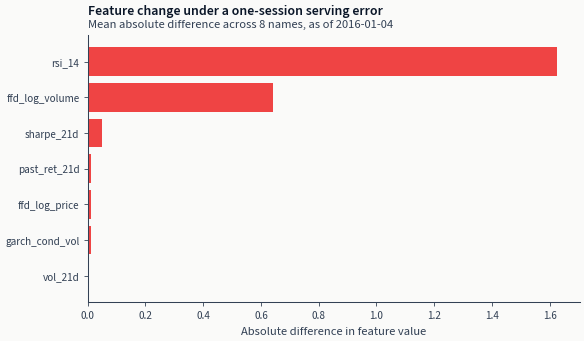

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ordered = skew_table.iloc[::-1]
ax.barh(ordered["feature"], ordered["mean_abs_delta"], color=COLORS["negative"])
add_message_title(
    ax,
    "Feature change under a one-session serving error",
    subtitle=f"Mean absolute difference across {N_SAMPLE_ASSETS} names, as of {as_of_date}",
)
ax.set_xlabel("Absolute difference in feature value")
show_with_alt(
    fig,
    "Horizontal bar chart, one bar per feature, sorted with the largest at the top. Each "
    "bar is the mean absolute difference between the feature value a correct as-of "
    "retrieval returns and the value the next-session retrieval returns.",
)

The bars are on different scales because the features are: a relative strength index runs
from 0 to 100 while an annualized volatility is a small decimal, so the chart ranks how far
each moved and does not compare them with each other. The bars near the axis are not zero -
the table above gives their sizes - and that is the point worth taking: one wrong comparison
operator moves the whole vector, not one feature of it.

The contract a store enforces is three sentences. The offline join takes the feature values
known at each decision timestamp. The online retrieval takes the last values known at the
moment of the decision, by the same rule. The registry says where both came from. Feast
automates all three, which is what `05b_feast_live` shows, and the reason to know what they
are is that a store configured with the wrong timestamp column automates the wrong one.

## Key Takeaways

1. A feature table needs an entity key, an event timestamp and a time to live before it can
   be served correctly. The first two make a point-in-time join possible; the third is what
   turns a missing row into an error instead of a stale answer.
2. Training and serving ask different queries of the same data - a join on exact dates, and
   a latest-at-or-before lookup - and the whole discipline is making them agree. Skew is what
   it is called when they do not.
3. Measure the skew rather than reasoning about it. One session of look-ahead is the smallest
   version of the mistake and it still moves every feature; a larger one is not visibly
   different in the code.
4. Guard the holdout boundary where the training set is built, and make the guard refuse. A
   join that quietly includes sessions the model may not see produces a training set that
   looks ordinary and an evaluation that means nothing.
5. Record lineage per view, including the count of distinct entity-timestamp keys. Rows above
   keys means the table holds more than one value per key, and the store's answer then
   depends on which one it happened to pick.

**Known limitations**

- The skew here is measured on the feature vectors, not on what a model does with them. A
  large move in a feature the model barely uses matters less than a small move in one it
  leans on, and nothing here weights them.
- Eight names on one date is enough to show that the error reaches every feature. It is not
  an estimate of the size of the error on any other date.
- The time to live is declared and not enforced: these retrievals filter on dates rather
  than checking staleness against the TTL. A real store rejects the stale read.
- The offline store here is two Parquet files read directly. A production store adds an
  online key-value tier for serving, and the consistency between the two tiers is its own
  problem, not covered here.

**Next**: See `05b_feast_live` for the same workflow automated with Feast, or `06_mlflow_experiments` for experiment tracking.